In [3]:
from glob import glob
import dask
import cftime
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cmo

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import xclimate as xclim

# How does large ensemble variability in SSP3-7.0 compare to our artificial repeating observed variability?

In [4]:
client_cluster = xclim.create_dask_cluster(
    account='UWAS0155',
    nworkers=2,
    ncores=1,
    nmem='20GB',
    walltime='02:00:00'
)

account:  UWAS0155
nworkers: 2
ncores:   1
nmemory:  20GB
walltime: 02:00:00
{'PBSCluster-0': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-1': <dask_jobqueue.pbs.PBSJob: status=running>}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 8787:128.117.211.160:8787 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:8787/status


In [1]:
# client_cluster[1]

In [ ]:
# xclim.close_dask_cluster(client_cluster)

# time period

In [5]:
tperiod = slice('2015-01', '2100-12')

# masks

In [11]:
ds = xr.open_dataset('/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1/AREA/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.AREA.195001-195912.nc')
area = ds.AREA.isel(time=0)

ds = xr.open_dataset('/glade/campaign/collections/gdex/data/d651056/CESM2-LE/lnd/proc/tseries/month_1/GPP/b.e21.BHISTcmip6.f09_g17.LE2-1301.006.clm2.h2.GPP.195001-195912.nc')
ds = ds.reindex_like(area, tolerance=1e-3, method='nearest')
a = (ds.area * 1e6).assign_attrs({'units': 'm2'})
lf = ds.landfrac
la = a * lf
lm = ~np.isnan(la)
om = ~lm
oa = area.where(om, other=0)

# load HadOI

In [7]:
hadbc = xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/atm/cam/sst/sst_HadOIBl_bc_0.9x1.25_1850_2022_c241003.nc')
obs = hadbc.SST_cpl_prediddle.sel(time=slice('1980-01', '2021-12')).reindex(lat=area.lat, lon=area.lon, method='nearest', tolerance=1e-3)

# load LENS2

In [8]:
xr.set_options(use_new_combine_kwarg_defaults=True)

v   = 'SST'
bb  = 'cmip6'
lens_dir = '/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1'
lens_starts = [
    '1001', '1021', '1041', '1061', '1081', '1101', '1121',
    '1141', '1161', '1181', '1231', '1251', '1281', '1301'
]

def load_member(yr: str, mem_str: str) -> xr.DataArray:
    """Open, time-concat, reindex, and mask one ensemble member."""
    files = sorted(
        glob(f'{lens_dir}/{v}/b.e21.BHIST{bb}.f09_g17.LE2-{yr}.{mem_str}.cam.h0.{v}.*.nc') +
        glob(f'{lens_dir}/{v}/b.e21.BSSP370{bb}.f09_g17.LE2-{yr}.{mem_str}.cam.h0.{v}.*.nc')
    )
    ds = xr.open_mfdataset(
        files,
        parallel=True,
        combine='by_coords',
        data_vars='minimal',
        coords='minimal',
        compat='override',
    )
    return (
        xclim.time_coord.shift_time(ds)
        .sel(time=tperiod)[v]
        .where(om)
    )

members = []
for im, yr in enumerate(lens_starts):
    print(f'- {yr}')
    if int(yr) < 1200:
        members.append(load_member(yr, str(im + 1).zfill(3)))
    else:
        for i in range(1, 11):
            print(str(i).zfill(3), end=' ')
            members.append(load_member(yr, str(i).zfill(3)))
        print()

lens = (
    xr.concat(members, dim='ens')
    .assign_coords(ens=np.arange(1, 51))
    .assign_attrs(units='deg_C')
    - 273.15
)
lens = lens.chunk({'time': -1}).persist()

- 1001


- 1021
- 1041
- 1061
- 1081
- 1101
- 1121
- 1141
- 1161
- 1181
- 1231
001 002 003 004 005 006 007 008 009 010 
- 1251
001 002 003 004 005 006 007 008 009 010 
- 1281
001 002 003 004 005 006 007 008 009 010 
- 1301
001 002 003 004 005 006 007 008 009 010 


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 17.48 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


# load LENS2 mean

In [12]:
# mlens = xr.open_dataset('/glade/campaign/univ/uwas0155/ppe/future/sst/b.e21.cmip6.f09_g17.LE2-ens-mean.cam.h0.SST.nc').SST.sel(time=slice('1980-01', '2100-12'))
mlens = lens.mean(dim='ens').chunk({'time': -1}).persist()

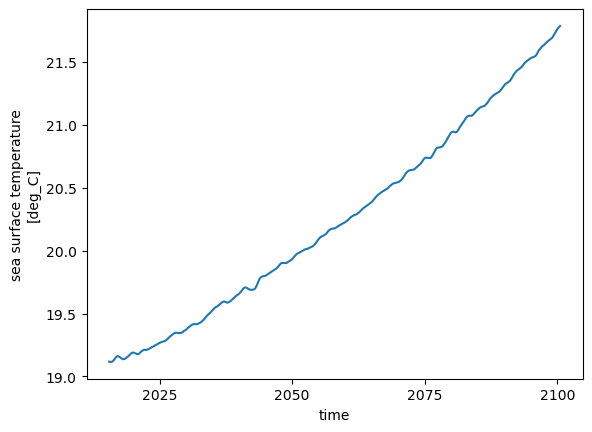

In [18]:
mlens.weighted(oa).mean(dim=['lat', 'lon']).rolling(time=12, center=True).mean().plot()

# compute artificial SST time series

In [13]:
def split_years_months(da):
    name = da.name
    years  = np.unique(da.time.dt.year.values)
    months = np.unique(da.time.dt.month.values)
    
    # Rechunk time dim contiguously before reshape
    da = da.chunk({'time': -1})
    
    new_shape = (len(years), len(months)) + da.shape[1:]
    new_dims  = ['year', 'month'] + list(da.dims[1:])
    
    extra_coords = {k: v for k, v in da.coords.items()
                    if 'time' not in v.dims}
    
    return xr.DataArray(
        da.data.reshape(new_shape),   # dask-safe
        dims=new_dims,
        coords={'year': years, 'month': months, **extra_coords}
    ).rename(name)

def combine_years_months(da, freq='MS'):
    name = da.name
    years  = da.year.values   # shape (Y,)
    months = da.month.values  # shape (M,)

    # Build full Y×M time index, then flatten
    yy, mm = np.meshgrid(years, months, indexing='ij')  # both (Y, M)
    time_index = xr.date_range(                        # or pd.date_range if using numpy datetimes
        start=f'{years[0]}-{months[0]:02d}',
        periods=len(years) * len(months),
        freq=freq,
        use_cftime=True
    )

    # Flatten year×month into time, preserve trailing spatial dims
    trailing_dims   = list(da.dims[2:])          # e.g. ['lat', 'lon']
    trailing_shape  = da.shape[2:]
    flat_data = da.data.reshape(len(time_index), *trailing_shape)  # dask-safe

    # Preserve non-(year,month) coords
    extra_coords = {k: v for k, v in da.coords.items()
                    if not any(d in ('year', 'month') for d in v.dims)}

    return xr.DataArray(
        flat_data,
        dims=['time'] + trailing_dims,
        coords={'time': time_index, **extra_coords}
    ).rename(name)

# def combine_years_months(da):
#     return da.stack(time=['year', 'month']).drop_vars(['time', 'year', 'month']).set_index(time='datetime')

def monthly_polyfit(group):
    decimal_years = group.time.dt.decimal_year
    decimal_years = decimal_years - decimal_years[0]
    g = group.assign_coords(time=decimal_years)
    pf = g.polyfit(dim='time', deg=1, skipna=True)
    return pf['polyfit_coefficients']

def monthly_detrend(y):
    coeffs = y.groupby('time.month').map(monthly_polyfit)
    slope_t = coeffs.sel(degree=1).sel(month=y.time.dt.month)

    t = y.time.dt.decimal_year
    t0_by_month = t.groupby('time.month').first()

    return y - (t.groupby('time.month') - t0_by_month) * slope_t

In [14]:
base_tperiod = [2007, 2021]

obsm = split_years_months(obs)
mlensm = split_years_months(mlens)

obsm_base = obsm.sel(year=slice(base_tperiod[0], base_tperiod[1])).mean(dim='year')
mlensm_base = mlensm.sel(year=slice(base_tperiod[0], base_tperiod[1])).mean(dim='year')

In [19]:
obs_years = obsm.year
coeffs = obsm.polyfit(dim='year', deg=1, skipna=True).polyfit_coefficients
trend = coeffs.sel(degree=1) # per year

obsm_dt = obsm - trend * (obs_years - obs_years[0])
obsm_dt_mean = obsm_dt.mean(dim='year')
obsm_dtdm = obsm_dt - obsm_dt_mean

In [20]:
obs_nyears = len(obsm_dtdm.year)
ens_nyears = len(mlensm.year)

n_stack = ens_nyears // obs_nyears + 1

obsm_dtdm_stack = xr.concat(n_stack * [obsm_dtdm], dim='year').isel(year=slice(0, ens_nyears)).assign_coords(year=mlensm.year)
assert mlensm.shape == obsm_dtdm_stack.shape

In [21]:
offset = obsm_base - mlensm_base
mlensm_offset = mlensm + offset
mlensm_var = mlensm + obsm_dtdm_stack
sstm = mlensm + offset + obsm_dtdm_stack

In [ ]:
mlens_offset = combine_years_months(mlensm_offset)
mlens_var = combine_years_months(mlensm_var)
sst = combine_years_months(sstm)

# plots

In [93]:
def detrend(da, tcoord):
    coeffs = da.polyfit(dim=tcoord, deg=1, skipna=True).polyfit_coefficients
    trend = coeffs.sel(degree=1) # per tcoord
    return da - trend * (da[tcoord] - da[tcoord][0])

In [45]:
mlens_var_gm_ann = mlens_var.weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().compute()
mlens_offset_gm_ann = mlens_offset.weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().compute()
lens_gm_ann = lens.weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().compute()
sst_gm_ann = sst.weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().compute()

In [50]:
lens_gm_ann_min = lens_gm_ann.min(dim='ens')
lens_gm_ann_max = lens_gm_ann.max(dim='ens')
lens_gm_ann_mean = lens_gm_ann.mean(dim='ens')
lens_gm_ann_std = lens_gm_ann.std(dim='ens')

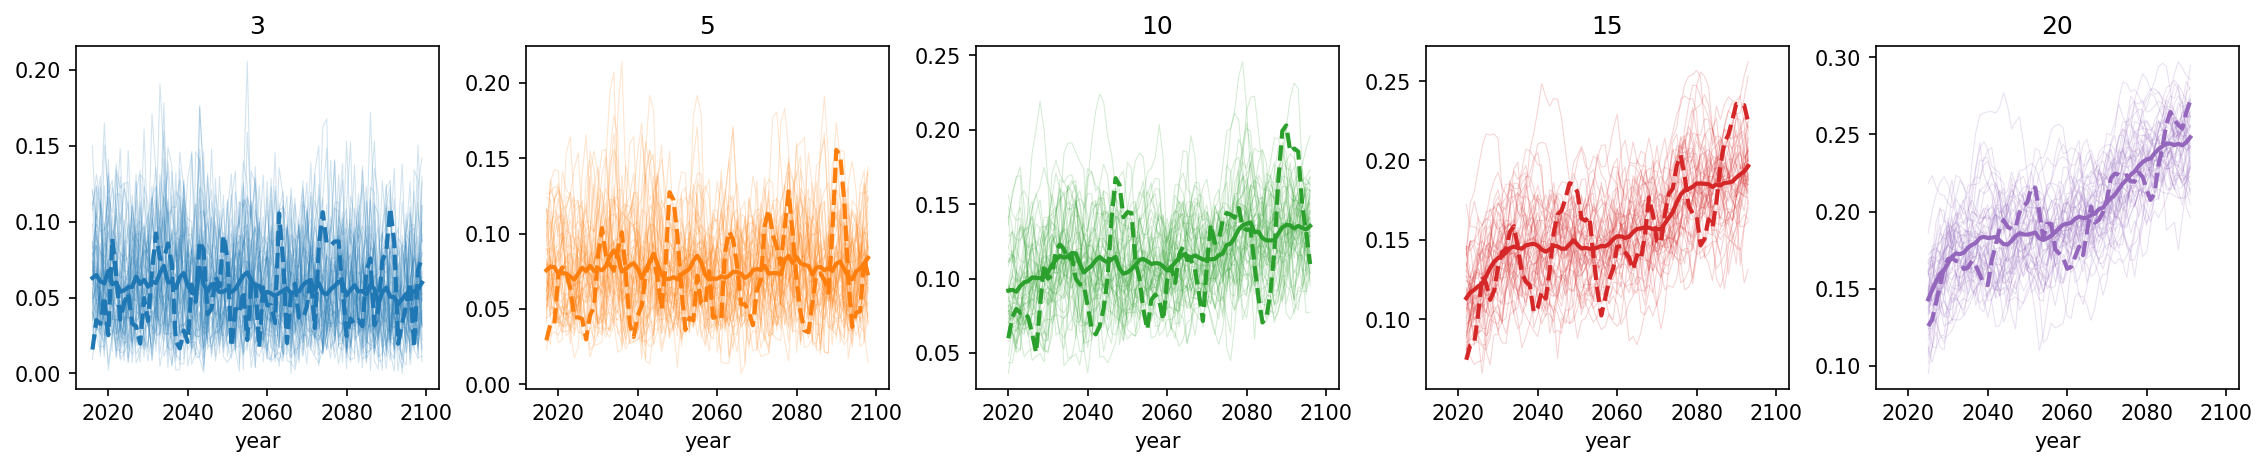

In [73]:
fig, ax = plt.subplots(1, 5, figsize=(15, 3), sharex=True, layout='constrained', dpi=150)

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
for i, window in enumerate([3, 5, 10, 15, 20]):
    lens_gm_ann.rolling(year=window, center=True).std().mean(dim='ens').plot(ax=ax[i], label=window, color=colors[i], lw=2)
    for ens in range(50):
        lens_gm_ann.isel(ens=ens).rolling(year=window, center=True).std().plot(ax=ax[i], color=colors[i], lw=0.5, alpha=0.2)
    sst_gm_ann.rolling(year=window, center=True).std().plot(ax=ax[i], color=colors[i], ls='--', lw=2)
    ax[i].set_title(window)

In [74]:
sst_region_bnds = {
    'nat': [[47, 57], [315, 335]],
    'sep': [[-62, -47], [220, 290]],
    'nep': [[35, 50], [190, 220]],
    'npa': [[30, 50], [150, 230]],
    'ind': [[-15, 5], [60, 90]],
    'sop': [[-62, -47], [100, 140]],
    'so': [[-90, -50], [0, 360]],
}

sst_region_names = {
    'nat': 'N. Atlantic box',
    'sep': 'S. East Pacific box',
    'nep': 'N. East Pacific box',
    'npa': 'N. Pacific box',
    'ind': 'Indian Ocean box',
    'sop': 'Southern Ocean box',
    'so': 'Southern Ocean',
}

sst_regions = {}
for name, bnds in sst_region_bnds.items():
    lat_bnds = bnds[0]
    lon_bnds = bnds[1]
    reg = obs.isel(time=0).drop_vars('time')
    reg = ((reg.lat >= lat_bnds[0]) & (reg.lat < lat_bnds[1]) & (reg.lon >= lon_bnds[0]) & (reg.lon < lon_bnds[1]))
    sst_regions[name] = reg.where(om).rename(name)

Text(0.5, 0.98, 'running standard deviation of regional-mean SST [$^{\\circ}$C]')

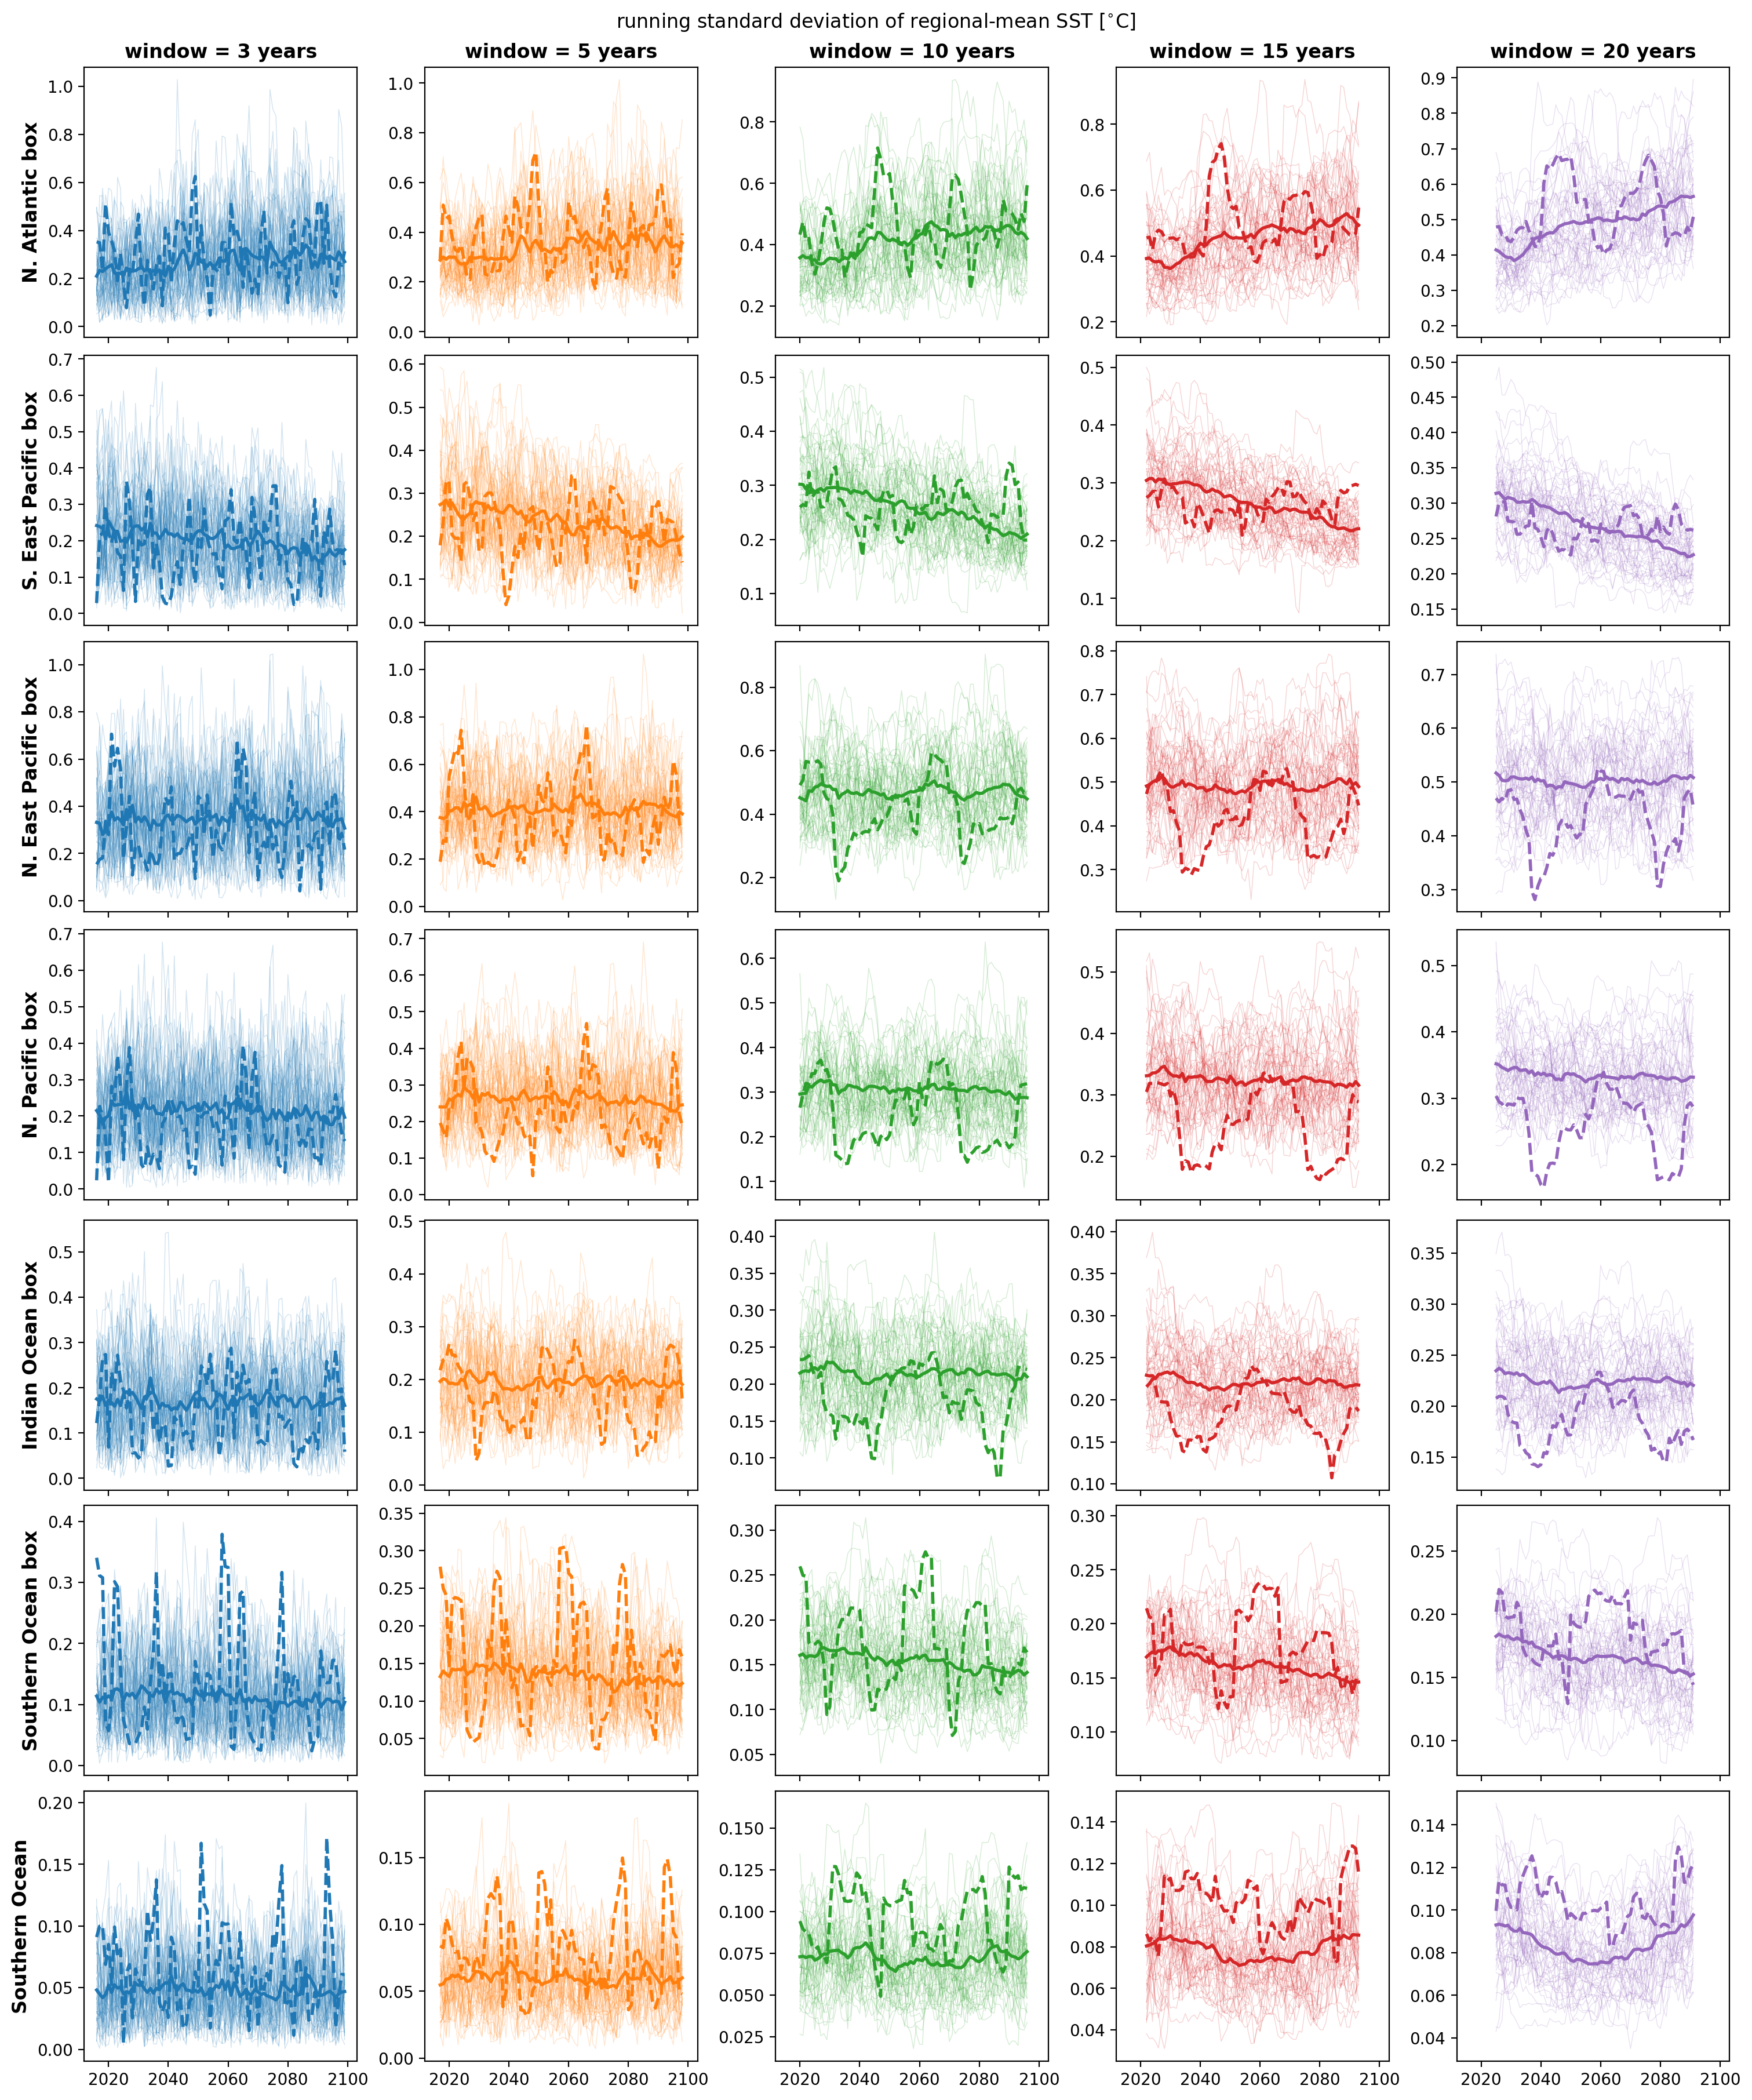

In [97]:

fig, ax = plt.subplots(7, 5, figsize=(15, 18), sharex=True, layout='constrained', dpi=200)

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

for j, (name, reg) in enumerate(sst_regions.items()):

    lens_reg_ann = lens.where(reg).weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().persist()
    sst_reg_ann = sst.where(reg).weighted(oa).mean(dim=['lat', 'lon']).groupby('time.year').mean().persist()

    lens_reg_ann_dt = detrend(lens_reg_ann, 'year')
    sst_reg_ann_dt = detrend(sst_reg_ann, 'year')

    for i, window in enumerate([3, 5, 10, 15, 20]):
        lens_reg_ann_dt_std = lens_reg_ann_dt.rolling(year=window, center=True).std().compute()
        for ens in range(50):
            lens_reg_ann_dt_std.isel(ens=ens).plot(ax=ax[j, i], color=colors[i], lw=0.5, alpha=0.2)
        lens_reg_ann_dt_std.mean(dim='ens').plot(ax=ax[j, i], label=window, color=colors[i], lw=2)
        sst_reg_ann_dt.rolling(year=window, center=True).std().plot(ax=ax[j, i], color=colors[i], ls='--', lw=2)

        ax[j, i].set_xlabel('')
        ax[j, i].set_ylabel('')

        if j == 0:
            ax[j, i].set_title(f'window = {window} years', fontweight='bold', fontsize='large')
        else:
            ax[j, i].set_title('')
    
    ax[j, 0].set_ylabel(sst_region_names[name], fontweight='bold', fontsize='large')

fig.suptitle('running standard deviation of regional-mean SST [$^{\\circ}$C]')

Text(0.5, 1.0, '')

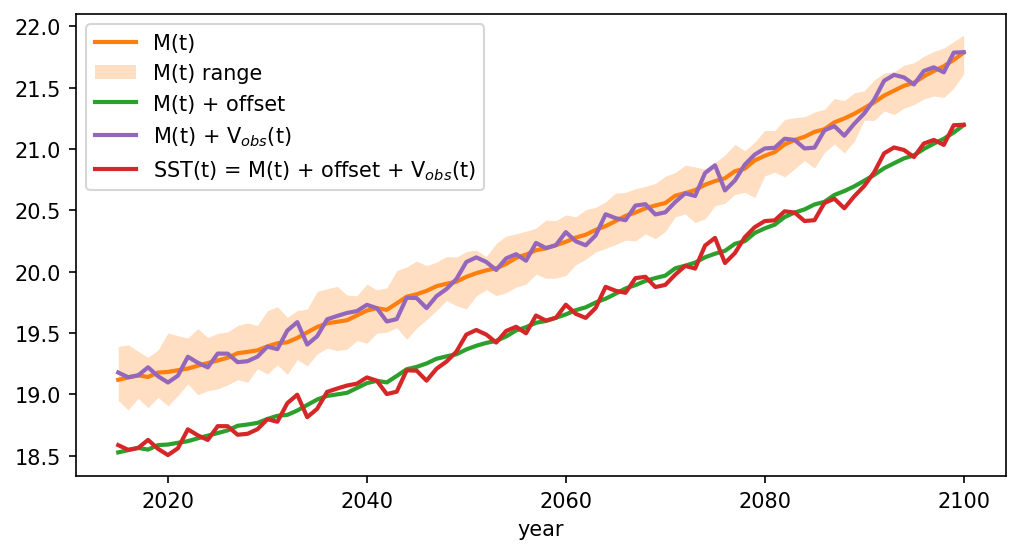

In [49]:
fig, ax = plt.subplots(figsize=(8,4), dpi=150)
lens_gm_ann_mean.plot(ax=ax, c='tab:orange', lw=2, label='M(t)')
ax.fill_between(
    lens_gm_ann.year,
    lens_gm_ann_min,
    lens_gm_ann_max,
    color='tab:orange',
    lw=0,
    alpha=0.25,
    label='M(t) range'
)
mlens_offset_gm_ann.plot(ax=ax, c='tab:green', lw=2, label='M(t) + offset')
mlens_var_gm_ann.plot(ax=ax, c='tab:purple', lw=2, label='M(t) + V$_{obs}$(t)')
sst_gm_ann.plot(ax=ax, c='tab:red', lw=2, label='SST(t) = M(t) + offset + V$_{obs}$(t)')
ax.legend()
ax.set_title('')

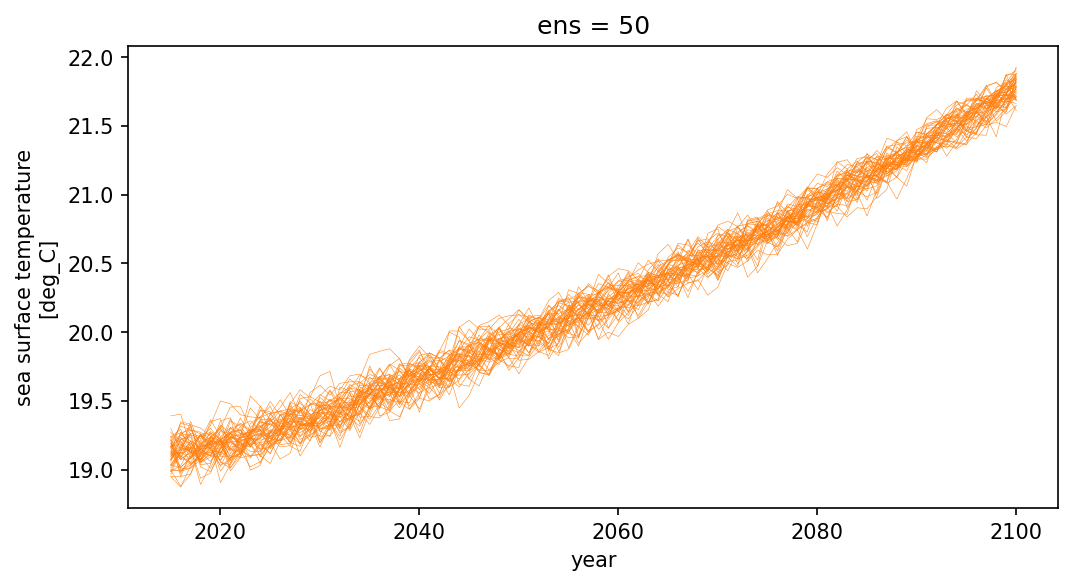

In [22]:
fig, ax = plt.subplots(figsize=(8,4), dpi=150)
for i in range(50):
    lens_gm_ann.isel(ens=i).plot(ax=ax, lw=0.25, c='tab:orange')

# load multimodel large ensembles

In [ ]:
directory = '/gdex/data/d651039'
models = [
    'access_lens',
    'canesm2_lens',
    'canesm5_lens',
    'cesm1_lens',
    'cesm2_lens',
    'csiro_mk36_lens',
    'e3sm_v1_lens',
    'e3sm_v2_lens',
    'ec-earth3_lens',
    'gfdl_cm3_lens',
    'gfdl_esm2m_lens',
    'gfdl_spear_lens',
    'giss-e2',
    'ipsl_cm6a_lens',
    'miroc6_lens',
    'miroc_esm2l_lens',
    'mpi_lens',
    'mpi_lens_cmip6',
    'ukesm1-0-ll_lens',
]

